# Chapter 5 - Fractionally Differentiated Features

## Preparation

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, coint
import scipy.optimize
from scipy import stats
from sklearn.metrics import r2_score
from pprint import pprint

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample, shuffle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj
from utils.labeling import get_daily_vol, symmetric_cusum_filter, get_vertical_bars, apply_pt_sl_on_t1, get_events, get_bins
from utils.frac_diff import expanding_window_fracdiff, frac_diff_ffd

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
close = dollar_bars["price"].sort_index()

## 1. Generate a time series from an IID Gaussian random process. This is a memory-less, stationary series:

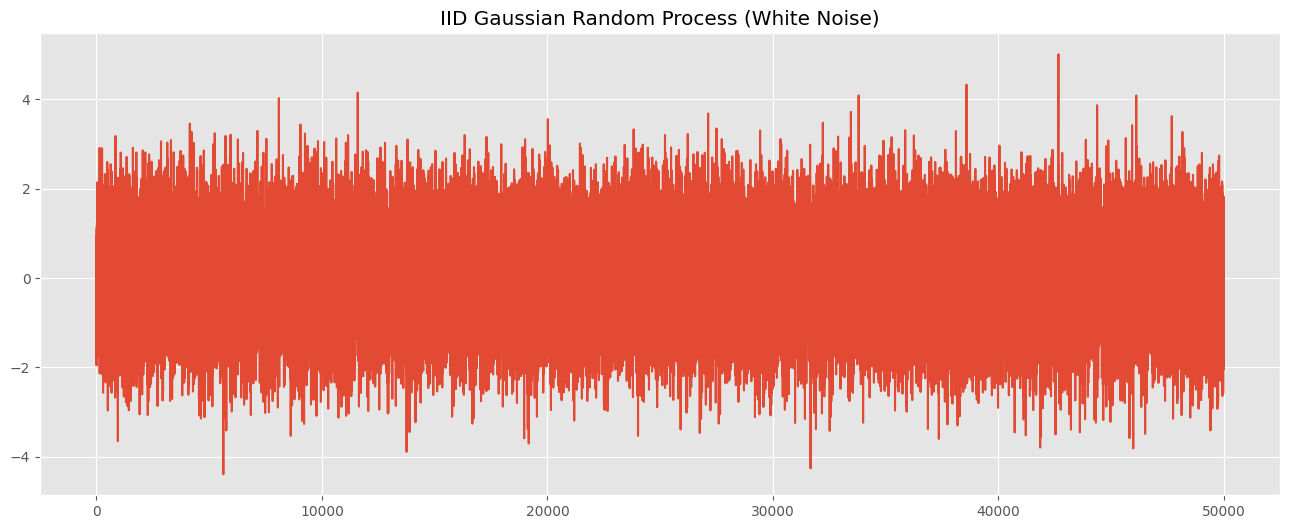

In [3]:
n_samples = 50000  # Number of points in the process
mu = 0            # Mean
sigma = 1         # Standard deviation

rng = np.random.default_rng(seed=42)
iid_process = rng.normal(loc=mu, scale=sigma, size=n_samples)

# Visualize the process
plt.plot(iid_process)
plt.title("IID Gaussian Random Process (White Noise)")
plt.show()

### a. Compute the ADF statistic on this series. What is the p-value?

In [4]:
result = adfuller(iid_process)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values: {result[4]}')

ADF Statistic: -223.19028852196203
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4304807953310763), '5%': np.float64(-2.8615978088501315), '10%': np.float64(-2.566800769739017)}


### b. Compute the cumulative sum of the observations. This is a nonstationary  series without memory.

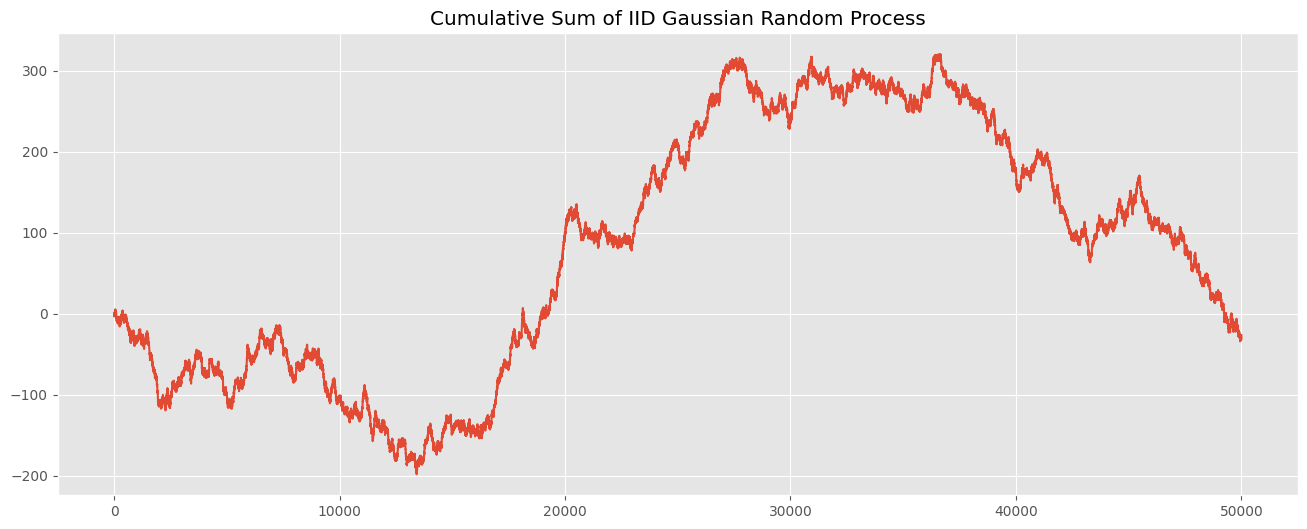

In [5]:
cum_sum = iid_process.cumsum()

plt.plot(cum_sum)
plt.title("Cumulative Sum of IID Gaussian Random Process")
plt.show()

#### i. What is the order of integration of this cumulative series?

This is order of integration of 1, since it takes 1 differentiation to make the time series to become stationary.

#### ii. Compute the ADF statistic on this series. What is the p-value?

In [6]:
result_cum_sum = adfuller(cum_sum)

print(f'ADF Statistic: {result_cum_sum[0]}')
print(f'p-value: {result_cum_sum[1]}')
print(f'Critical Values: {result_cum_sum[4]}')

ADF Statistic: -0.6562822533526006
p-value: 0.8577508677942011
Critical Values: {'1%': np.float64(-3.4304807953310763), '5%': np.float64(-2.8615978088501315), '10%': np.float64(-2.566800769739017)}


### c. Differentiate the series twice. What is the p-value of this overdifferentiated series?

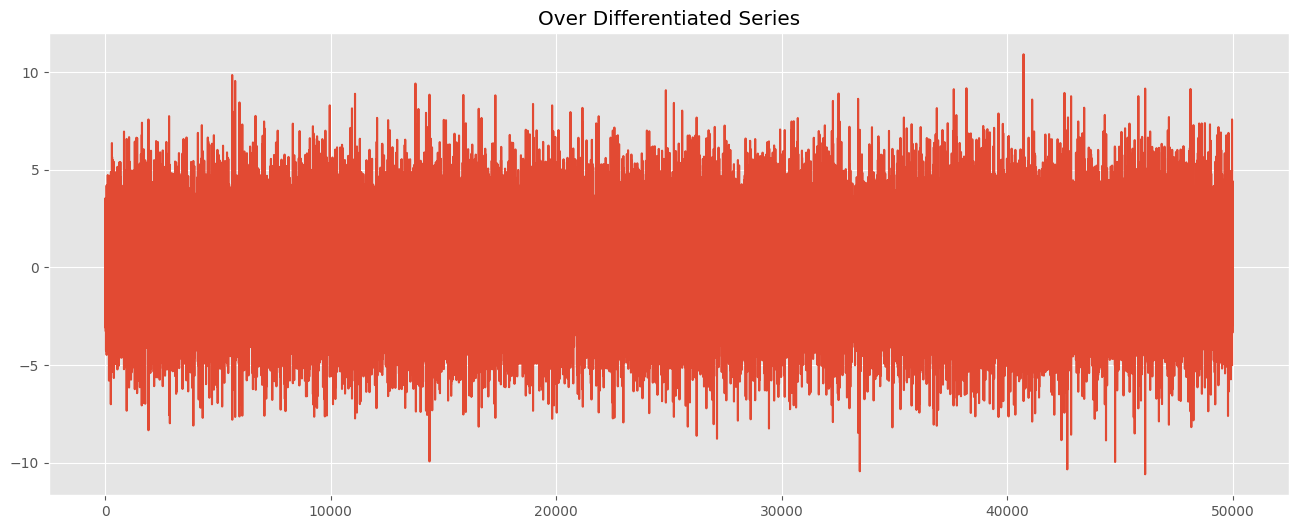

ADF Statistic: -65.44522359364991
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430480949862939), '5%': np.float64(-2.8615978771485344), '10%': np.float64(-2.5668008060922607)}


In [7]:
over_diff_process = np.diff(np.diff(iid_process))

plt.plot(over_diff_process)
plt.title("Over Differentiated Series")
plt.show()

result_over_diff = adfuller(over_diff_process)

print(f'ADF Statistic: {result_over_diff[0]}')
print(f'p-value: {result_over_diff[1]}')
print(f'Critical Values: {result_over_diff[4]}')

Although the overly differentiated time series is also stationary, the variance is inflated, and we create a MA(1) series, compared to the original I(0) IID time series.

## Setup

Let $\{\varepsilon_t\}_{t=1}^{n} \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$. Applying `np.diff` to this already-stationary series **over-differences** it, producing:

$$ D_t = \varepsilon_t - \varepsilon_{t-1}, \quad t = 2, 3, \ldots, n $$

## Mean

By linearity of expectation:

$$ \mathbb{E}[D_t] = \mathbb{E}[\varepsilon_t] - \mathbb{E}[\varepsilon_{t-1}] = 0 - 0 = 0 $$

The mean remains **0**.[1]

## Variance

Since $\varepsilon_t$ and $\varepsilon_{t-1}$ are **independent** (IID assumption), the variance of their difference is:

$$ \text{Var}(D_t) = \text{Var}(\varepsilon_t) + \text{Var}(\varepsilon_{t-1}) = \sigma^2 + \sigma^2 = 2\sigma^2 $$

The variance **doubles** relative to the original process.[1]

## Key Consequence: Induced Autocorrelation

Over-differencing does not just inflate variance — it introduces a **negative MA(1) structure**. The lag-1 autocovariance is:

$$ \text{Cov}(D_t, D_{t-1}) = \text{Cov}(\varepsilon_t - \varepsilon_{t-1},\ \varepsilon_{t-1} - \varepsilon_{t-2}) = -\sigma^2 $$

This gives a lag-1 autocorrelation of:

$$ \rho_1 = \frac{-\sigma^2}{2\sigma^2} = -\frac{1}{2} $$

All higher lags $\rho_k = 0$ for $|k| \geq 2$. So `np.diff` of an IID process yields an **MA(1) process with coefficient $$\theta = -1$$** — a telltale sign of over-differencing in practice [2].

## Summary

| Property | Original $\varepsilon_t$ | Over-differenced $D_t$ |
|---|---|---|
| Mean | 0 | 0 |
| Variance | $\sigma^2$ | $2\sigma^2$ |
| Autocorrelation $\rho_1$ | 0 | $-1/2$ |
| Process type | I(0) white noise | MA(1), $\theta = -1$ |

## 2. Generate a time series that follows a sinusoidal function. This is a stationary  series with memory.

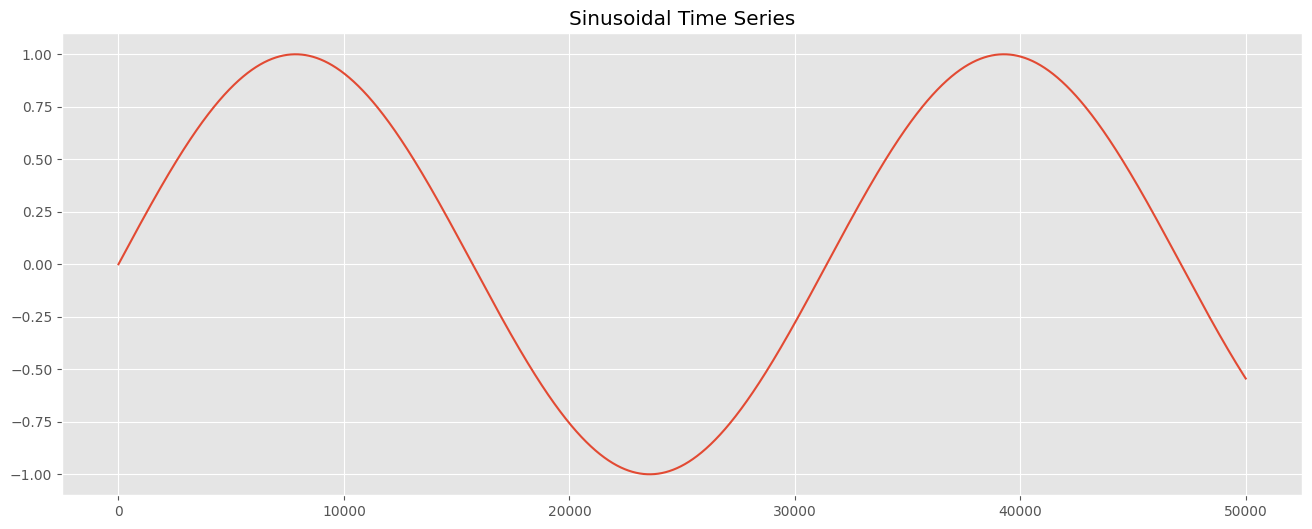

In [8]:
n_samples = 50000

sin_func = np.sin(np.linspace(0, 10, n_samples))

plt.plot(sin_func)
plt.title("Sinusoidal Time Series")
plt.show()

### a. Compute the ADF statistic on this series. What is the p-value?

In [9]:
result_sin_func = adfuller(sin_func)

print(f'ADF Statistic: {result_sin_func[0]}')
print(f'p-value: {result_sin_func[1]}')
print(f'Critical Values: {result_sin_func[4]}')

ADF Statistic: -208192930543.0748
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4304808424377145), '5%': np.float64(-2.861597829669839), '10%': np.float64(-2.566800780820739)}


### b. Shift every observation by the same positive value. Compute the  cumulative sum of the observations. This is a nonstationary series with memory.

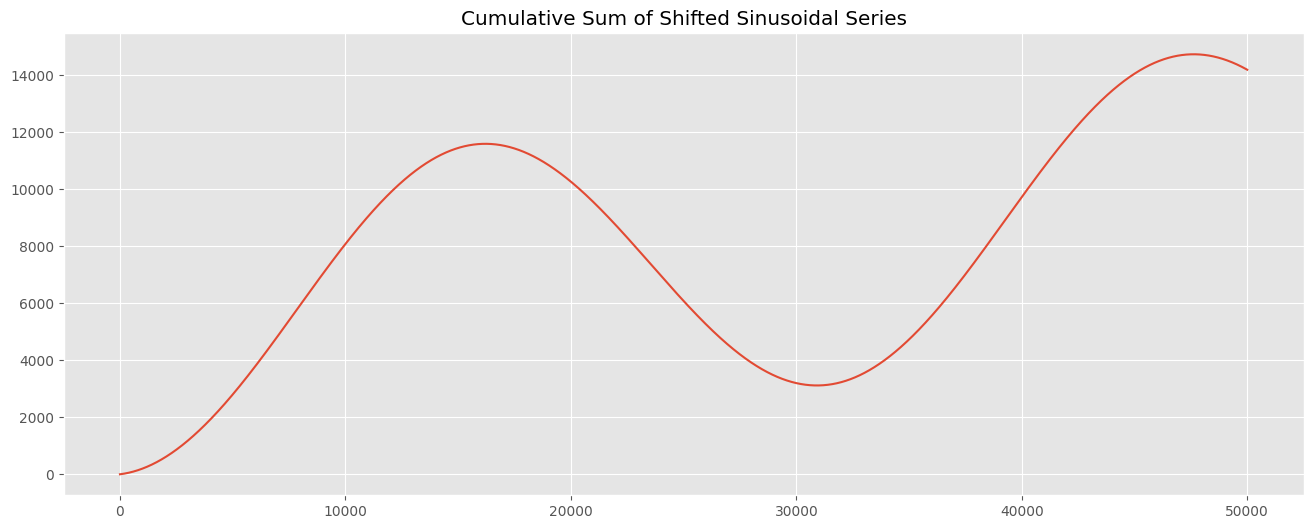

In [10]:
shift_val = 0.1
# shift the series
shifted_sin_func = sin_func + shift_val

# compute the cumulative sum
cum_sum_sin_shifted = shifted_sin_func.cumsum()

# plot the series
plt.plot(cum_sum_sin_shifted)
plt.title("Cumulative Sum of Shifted Sinusoidal Series")
plt.show()


#### i. Compute the ADF statistic on this series. What is the p-value?

In [11]:
result_cum_sum_sin_shifted = adfuller(cum_sum_sin_shifted)

print(f'ADF Statistic: {result_cum_sum_sin_shifted[0]}')
print(f'p-value: {result_cum_sum_sin_shifted[1]}')
print(f'Critical Values: {result_cum_sum_sin_shifted[4]}')

ADF Statistic: 2.535861725334181
p-value: 0.9990605096237865
Critical Values: {'1%': np.float64(-3.430480944618592), '5%': np.float64(-2.8615978748306916), '10%': np.float64(-2.566800804858541)}


#### ii. Apply an expanding window fracdiff, with τ = 1E − 2. For what  minimum d value do you get a p-value below 5%?

Minimum d value to get p-value < 5%: 0.5555555555555556


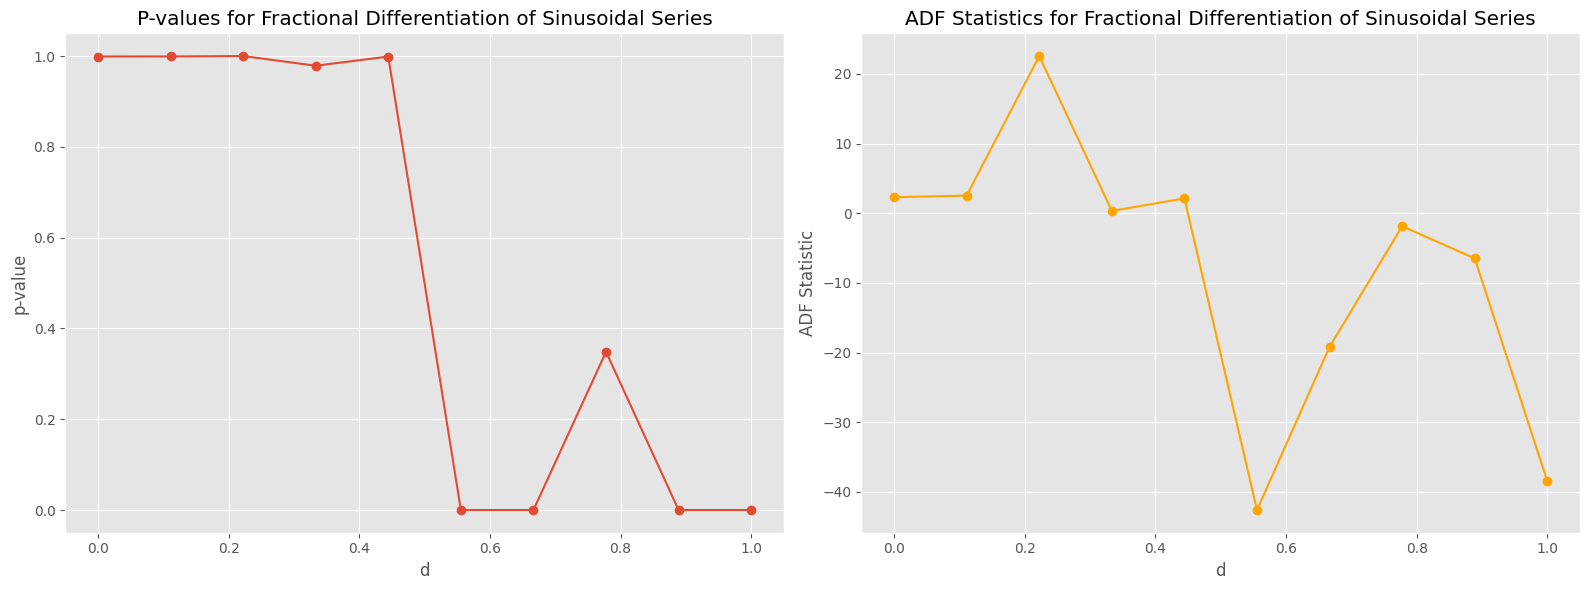

In [13]:
p_values = []
adf_stats = []

min_d = None

x_range_0_1 = np.linspace(0, 1, 10)

for d in x_range_0_1:
    frac_diff = expanding_window_fracdiff(pd.DataFrame({'s': cum_sum_sin_shifted}), d)['s'].dropna()
    result_frac_diff = adfuller(frac_diff)
    p_values.append(result_frac_diff[1])
    adf_stats.append(result_frac_diff[0])

    if result_frac_diff[1] < 0.05 and min_d is None:
        min_d = d

print(f"Minimum d value to get p-value < 5%: {min_d}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_range_0_1, p_values, marker='o')
axes[0].set_title("P-values for Fractional Differentiation of Sinusoidal Series")
axes[0].set_xlabel("d")
axes[0].set_ylabel("p-value")

axes[1].plot(x_range_0_1, adf_stats, marker='o', color='orange')
axes[1].set_title("ADF Statistics for Fractional Differentiation of Sinusoidal Series")
axes[1].set_xlabel("d")
axes[1].set_ylabel("ADF Statistic")

plt.tight_layout()
plt.show()

#### iii. Apply FFD, with τ = 1E − 5. For what minimum d value do you get a p-value below 5%?

Minimum d value to get p-value < 5%: 0.1111111111111111


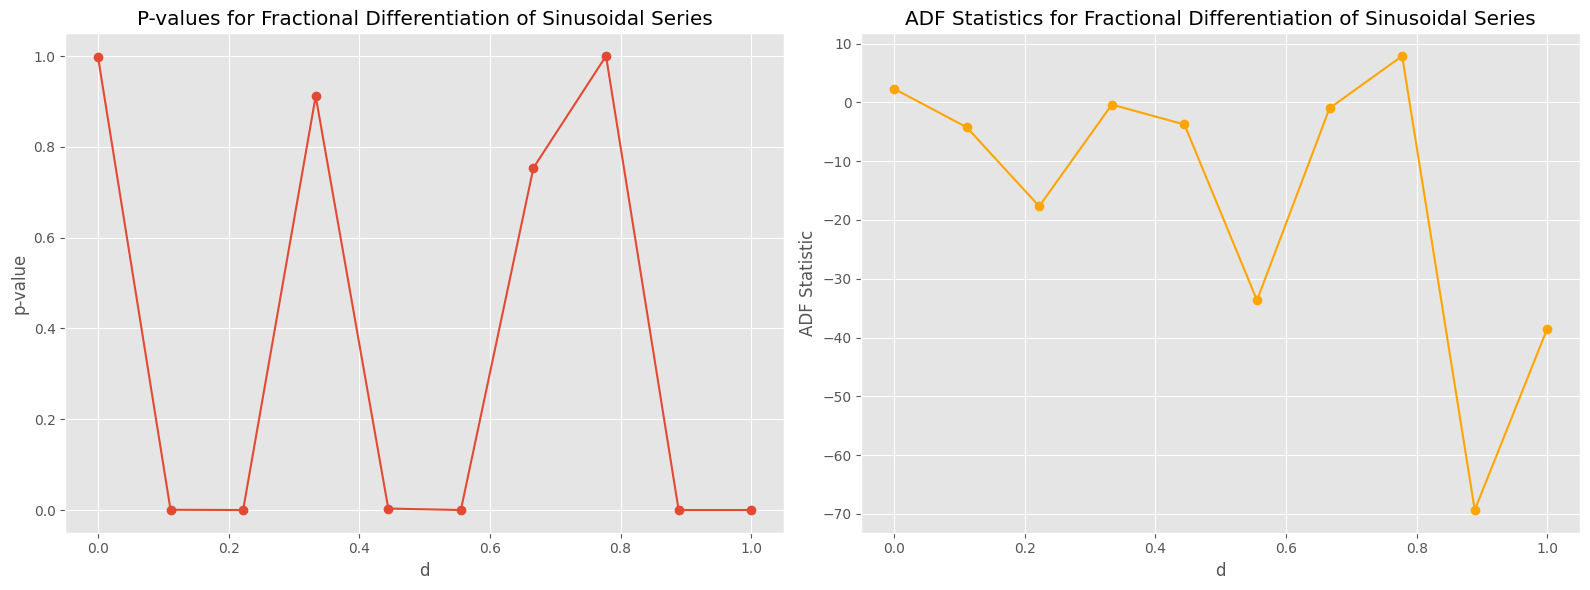

In [14]:
p_values = []
adf_stats = []

min_d = None

for d in x_range_0_1:
    frac_diff = expanding_window_fracdiff(pd.DataFrame({'s': cum_sum_sin_shifted}), d, tau=1e-5)['s'].dropna()
    result_frac_diff = adfuller(frac_diff)
    p_values.append(result_frac_diff[1])
    adf_stats.append(result_frac_diff[0])

    if result_frac_diff[1] < 0.05 and min_d is None:
        min_d = d

print(f"Minimum d value to get p-value < 5%: {min_d}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_range_0_1, p_values, marker='o')
axes[0].set_title("P-values for Fractional Differentiation of Sinusoidal Series")
axes[0].set_xlabel("d")
axes[0].set_ylabel("p-value")

axes[1].plot(x_range_0_1, adf_stats, marker='o', color='orange')
axes[1].set_title("ADF Statistics for Fractional Differentiation of Sinusoidal Series")
axes[1].set_xlabel("d")
axes[1].set_ylabel("ADF Statistic")

plt.tight_layout()
plt.show()

## 3. Take the series from exercise 2.b:

### a. Fit the series to a sine function. What is the $R^2$?

In [15]:
def fit_sin(tt, yy):
    '''Fit sin to the input time sequence, and return fitting parameters "amp", "omega", "phase", "offset", "freq", "period" and "fitfunc"'''
    # humbly re-appropriated from https://stackoverflow.com/a/42322656
    tt = np.array(tt)
    yy = np.array(yy)

    ff = np.fft.fftfreq(len(tt), (tt[1]-tt[0]))   # assume uniform spacing
    Fyy = abs(np.fft.fft(yy))

    guess_freq = abs(ff[np.argmax(Fyy[1:])+1])   # excluding the zero frequency "peak", which is related to offset
    guess_amp = np.std(yy) * 2.**0.5
    guess_offset = np.mean(yy)
    guess = np.array([guess_amp, 2.*np.pi*guess_freq, 0., guess_offset])

    print(f"guess_freq: {guess_freq}")
    print(f"guess_amp: {guess_amp}")
    print(f"guess_offset: {guess_offset}")

    def sinfunc(t, A, w, p, c):  return A * np.sin(w*t + p) + c
    popt, pcov = scipy.optimize.curve_fit(sinfunc, tt, yy, p0=guess)
    A, w, p, c = popt
    f = w/(2.*np.pi)
    fitfunc = lambda t: A * np.sin(w*t + p) + c
    return {"amp": A, "omega": w, "phase": p, "offset": c, "freq": f, "period": 1./f, "fitfunc": fitfunc, "maxcov": np.max(pcov), "rawres": (guess,popt,pcov)}

In [16]:
res = fit_sin(np.linspace(0, 10, n_samples), cum_sum_sin_shifted)

res

guess_freq: 0.199996
guess_amp: 5892.250248549384
guess_offset: 7772.033559405229


{'amp': np.float64(-5467.702778515793),
 'omega': np.float64(1.0732031226478962),
 'phase': np.float64(1.1724717219292482),
 'offset': np.float64(7567.769642345039),
 'freq': np.float64(0.1708055819110703),
 'period': np.float64(5.854609602399579),
 'fitfunc': <function __main__.fit_sin.<locals>.<lambda>(t)>,
 'maxcov': np.float64(47.796426064915416),
 'rawres': (array([5.89225025e+03, 1.25661193e+00, 0.00000000e+00, 7.77203356e+03]),
  array([-5.46770278e+03,  1.07320312e+00,  1.17247172e+00,  7.56776964e+03]),
  array([[ 4.77964261e+01,  1.16550661e-04, -1.12702458e-03,
           2.32486931e+00],
         [ 1.16550661e-04,  2.74591404e-07, -1.37807651e-06,
           2.75495636e-04],
         [-1.12702458e-03, -1.37807651e-06,  8.86717723e-06,
          -2.92977692e-03],
         [ 2.32486931e+00,  2.75495636e-04, -2.92977692e-03,
           2.71693659e+01]]))}

R2 score: 0.9262711318098467


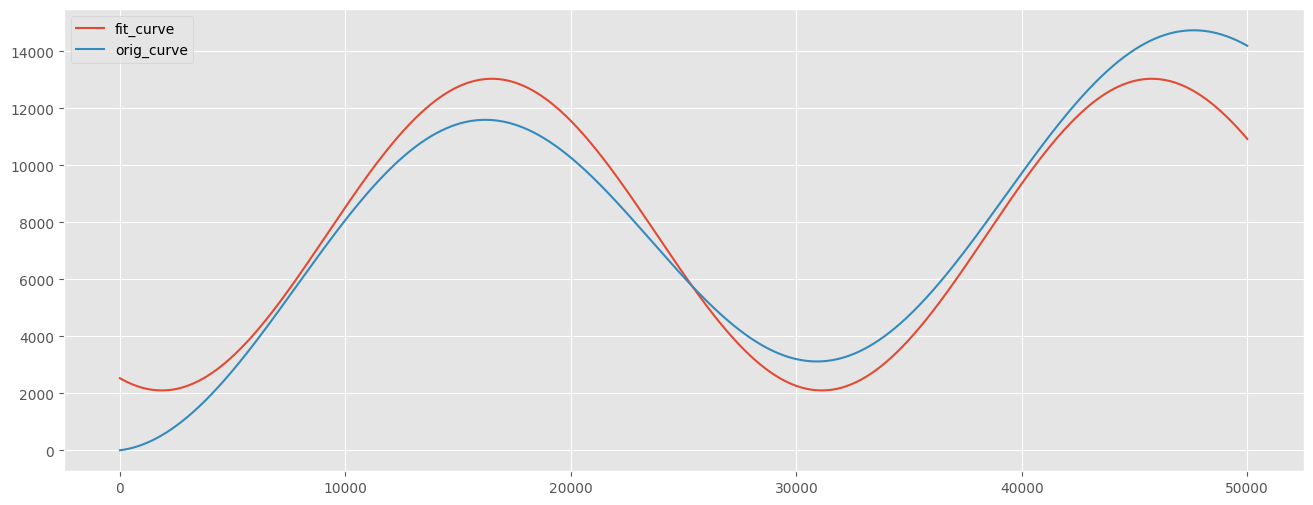

In [17]:
fit_curve = pd.Series(res['fitfunc'](np.linspace(0, 10, n_samples)))
pd.DataFrame({'fit_curve': fit_curve, 'orig_curve': cum_sum_sin_shifted}).plot()

print("R2 score:", r2_score(cum_sum_sin_shifted, fit_curve))

### b. Apply FFD(d = 1). Fit the series to a sine function. What is the $R^2$?

guess_freq: 0.1999959998399936
guess_amp: 0.9416662695407912
guess_offset: 0.28390538615580785

{'amp': np.float64(0.9999999999999983),
 'fitfunc': <function fit_sin.<locals>.<lambda> at 0x11d434540>,
 'freq': np.float64(0.15914857676684668),
 'maxcov': np.float64(2.3742327277163419e-29),
 'offset': np.float64(0.09999999999998985),
 'omega': np.float64(0.9999599991999935),
 'period': np.float64(6.283436649672363),
 'phase': np.float64(0.0004000080001327968),
 'rawres': (array([0.94166627, 1.25661193, 0.        , 0.28390539]),
            array([1.00000000e+00, 9.99959999e-01, 4.00008000e-04, 1.00000000e-01]),
            array([[ 7.04210228e-30,  1.27371591e-31, -9.93144638e-31,
        -1.25639531e-30],
       [ 1.27371591e-31,  6.65116324e-31, -3.43660017e-30,
         2.73787962e-31],
       [-9.93144638e-31, -3.43660017e-30,  2.37423273e-29,
        -1.02729242e-30],
       [-1.25639531e-30,  2.73787962e-31, -1.02729242e-30,
         3.47759309e-30]]))}

R2 score: 1.0


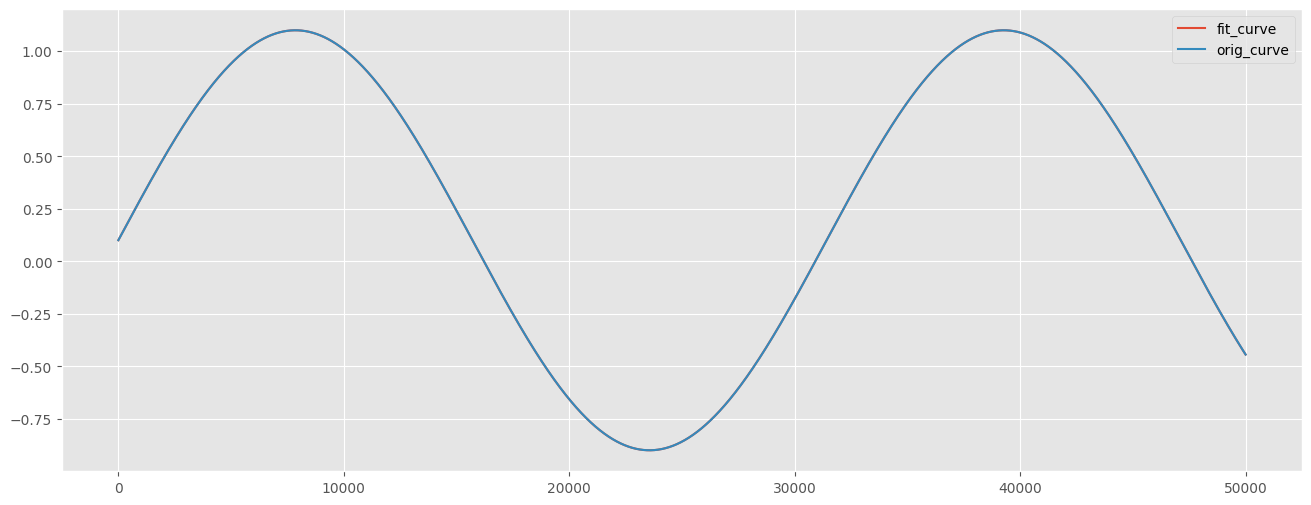

In [18]:
cum_sum_sin_shifted_frac_diff = expanding_window_fracdiff(pd.DataFrame({'s': cum_sum_sin_shifted}), d=1)['s'].dropna()

res = fit_sin(np.linspace(0, 10, len(cum_sum_sin_shifted_frac_diff)), cum_sum_sin_shifted_frac_diff)

print()
pprint(res)

fit_curve = pd.Series(res['fitfunc'](np.linspace(0, 10, len(cum_sum_sin_shifted_frac_diff))))
pd.DataFrame({'fit_curve': fit_curve, 'orig_curve': cum_sum_sin_shifted_frac_diff}).plot()

print("\nR2 score:", r2_score(cum_sum_sin_shifted_frac_diff, fit_curve))

### c. What value of d maximizes the $R^2$ of a sinusoidal fit on FFD(d).  Why?

guess_freq: 0.1999959999199984
guess_amp: 5892.104137146604
guess_offset: 7772.189001185252
guess_freq: 0.09999520015359509
guess_amp: 2295.986945039599
guess_offset: 2893.9824478517394
guess_freq: 0.09999686648074453
guess_amp: 798.200074983091
guess_offset: 781.9958447559499
guess_freq: 0.09999770810414375
guess_amp: 292.5558656391402
guess_offset: 288.0675659621205
guess_freq: 0.09999794272547728
guess_amp: 109.12740235633066
guess_offset: 88.54389619002899
guess_freq: 0.09999798800853084
guess_amp: 41.87098931123951
guess_offset: 27.985549240320466
guess_freq: 0.09999799679487179
guess_amp: 16.129974948386835
guess_offset: 8.949787447807978
guess_freq: 0.09999799895945892
guess_amp: 6.237686727779376
guess_offset: 2.8560637850026085
guess_freq: 0.19999599927987038
guess_amp: 2.420000465349558
guess_offset: 0.9052888777945699
guess_freq: 0.1999959998399936
guess_amp: 0.9416662695407912
guess_offset: 0.28390538615580785
1.0


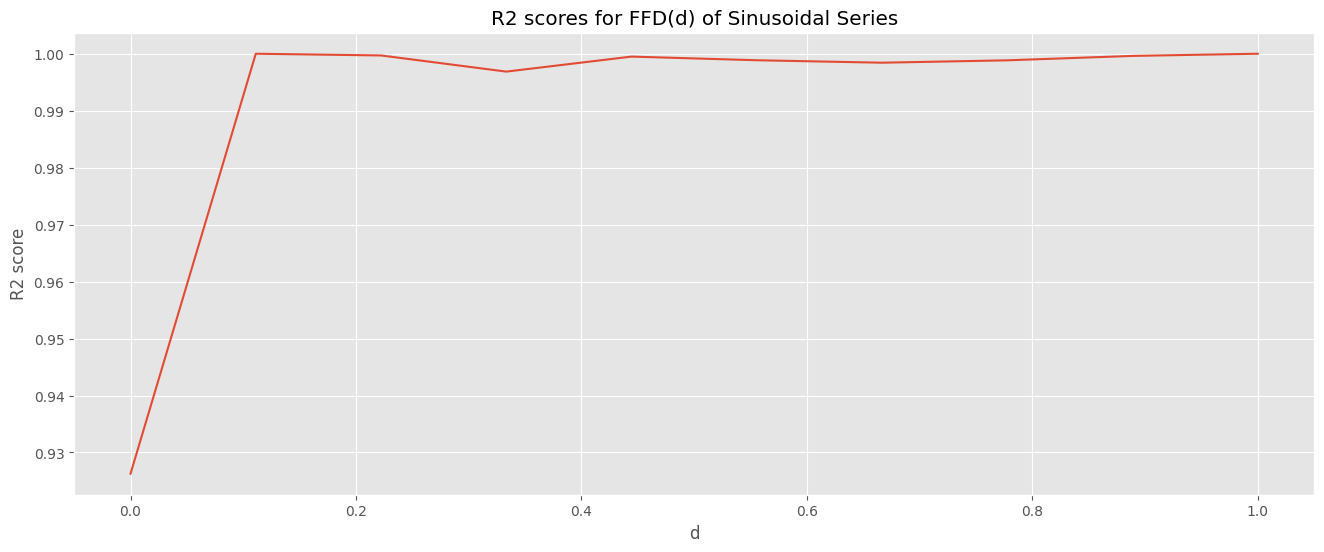

In [19]:
r2_scores = []

for d in x_range_0_1:
    frac_diff = expanding_window_fracdiff(pd.DataFrame({'s': cum_sum_sin_shifted}), d)['s'].dropna()
    res = fit_sin(np.linspace(0, 10, len(frac_diff)), frac_diff)
    r2_scores.append(r2_score(frac_diff, res['fitfunc'](np.linspace(0, 10, len(frac_diff)))))

print(x_range_0_1[np.argmax(r2_scores)])

plt.plot(x_range_0_1, r2_scores)
plt.title("R2 scores for FFD(d) of Sinusoidal Series")
plt.xlabel("d")
plt.ylabel("R2 score")
plt.show()

## 4. Take the dollar bar series on E-mini S&P 500 futures. Using the code in  Snippet 5.3, for some d ∈ [0, 2], compute  fracDiff_FFD(fracDiff_FFD(series,d),-d). What do you get? Why?

In [21]:
# x_range_0_2 = np.linspace(0, 2, 20)

# fd_list = []

# for d in x_range_0_2:
#     double_frac_diff = frac_diff_ffd(frac_diff_ffd(dollar_bars[['price']], d), -d)
#     fd_list.append(double_frac_diff)

# # sample some of the frac diff results and plot the graph
# sample_fd = fd_list[0]
# sample_fd.plot()
# plt.show()

# # plot the graph of the original series
# dollar_bars.plot()
# plt.show()

We will get a infinitely running process, as the calculated weight will never exceed threshold.

### d. Apply an Engel-Granger cointegration test on the original and fracdiff  series. Are they cointegrated? Why?

In [ ]:
score, pvalue, crit_value = coint(dollar_bars['log_price'], frac_diff_ffd_log_price_best)

print(f"Engel-Granger cointegration test score: {score}")
print(f"Engel-Granger cointegration test p-value: {pvalue}")
print(f"Engel-Granger cointegration test critical value: {crit_value}")

They are not cointegrated.

### e. Apply a Jarque-Bera normality test on the fracdiff series.

In [ ]:
res = stats.jarque_bera(frac_diff_ffd_log_price_best)

print(f"JB Statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")

## 6. Take the fracdiff series from exercise 5.

### a. Apply a CUSUM filter (Chapter 2), where h is twice the standard  deviation of the series.

In [ ]:
daily_vol = get_daily_vol(frac_diff_ffd_log_price_best, span0=1000)
t_events = symmetric_cusum_filter(frac_diff_ffd_log_price_best, daily_vol * 2)
len(t_events), t_events[:5]

### b. Use the filtered timestamps to sample a features’ matrix. Use as one of  the features the fracdiff value.

In [ ]:
def relative_strength_index(df, n):
    """ Calculate Relative Strength Index(RSI) for given data.
    https://github.com/Crypto-toolbox/pandas-technical-indicators/blob/master/technical_indicators.py

    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    i = 0
    UpI = [0]
    DoI = [0]
    while i + 1 <= df.index[-1]:
        UpMove = df.loc[i + 1, 'high'] - df.loc[i, 'high']
        DoMove = df.loc[i, 'low'] - df.loc[i + 1, 'low']
        if UpMove > DoMove and UpMove > 0:
            UpD = UpMove
        else:
            UpD = 0
        UpI.append(UpD)
        if DoMove > UpMove and DoMove > 0:
            DoD = DoMove
        else:
            DoD = 0
        DoI.append(DoD)
        i = i + 1
    UpI = pd.Series(UpI)
    DoI = pd.Series(DoI)
    PosDI = pd.Series(UpI.ewm(span=n, min_periods=n).mean())
    NegDI = pd.Series(DoI.ewm(span=n, min_periods=n).mean())
    RSI = pd.Series(round(PosDI * 100. / (PosDI + NegDI)), name='RSI_' + str(n))
    return RSI

# Compute RSI
def get_rsi(data, window=14):
    df = data.copy(deep=True).reset_index()
    rsi = relative_strength_index(df, window)
    rsi_df = pd.Series(data=rsi.values, index=data.index)
    return rsi_df

In [ ]:
rsi_df = get_rsi(dollar_bars, window=100)

rsi_df.head()

In [ ]:
dol_bars_feature = dollar_bars['price'].loc[t_events]
frac_diff_feature = frac_diff_ffd_log_price_best.loc[t_events]
rsi_feature = rsi_df[t_events]

features_matrix = (pd.DataFrame()
                .assign(dollar_bars=dol_bars_feature,
                        frac_diff=frac_diff_feature,
                        rsi=rsi_feature)
                .drop_duplicates().dropna())

features_matrix.head()

### c. Form labels using the triple-barrier method, with symmetric horizontal  barriers of twice the daily standard deviation, and a vertical barrier of 5 days.

In [ ]:
# Trend-following strategy: moving average crossover
# 1. Compute short-term and long-term moving averages
short_window = 50
long_window = 200

short_ma = frac_diff_ffd_log_price_best.rolling(window=short_window, min_periods=1).mean()
long_ma = frac_diff_ffd_log_price_best.rolling(window=long_window, min_periods=1).mean()

# 2. Generate signals DataFrame with column name 'side'
signal = pd.DataFrame(index=frac_diff_ffd_log_price_best.index)
signal['side'] = 0
signal.loc[short_ma > long_ma, 'side'] = 1
signal.loc[short_ma < long_ma, 'side'] = -1

# Remove look-ahead bias by lagging the signal
signal['side'] = signal['side'].shift(1)

# 3. (Optional) Save or view the strategy signals
signal.to_csv("trend_follow_signals.csv")
signal.head()

In [ ]:
vertical_bars = get_vertical_bars(frac_diff_ffd_log_price_best, t_events, num_days=5) # t1 in the text book

In [ ]:
pt_and_sl = daily_vol.mean() * 2

events = get_events(frac_diff_ffd_log_price_best, t_events=t_events, pt_sl=[pt_and_sl, pt_and_sl], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01, side=signal['side'])

bins = get_bins(events, frac_diff_ffd_log_price_best)

### d. Fit a bagging classifier of decision trees where:

In [ ]:
def get_ind_matrix(bar_idx, t1):
    # Get indicator matrix
    ind_matrix = pd.DataFrame(0, index=bar_idx, columns=range(t1.shape[0]))
    for i, (t0, t1) in enumerate(t1.items()):
        ind_matrix.loc[t0:t1, i] = 1.0
    return ind_matrix


def get_avg_uniqueness(ind_matrix):
    # Average uniqueness from indicator matrix
    concurrency = ind_matrix.sum(axis=1) # concurrency
    uniqueness = ind_matrix.div(concurrency, axis=0) # uniqueness
    avg_uniqueness = uniqueness[uniqueness>0].mean()
    return avg_uniqueness


def sequential_bootstrap(ind_matrix, n_bootstrap=100):
    # Sequential bootstrap
    if n_bootstrap is None:
        n_bootstrap = ind_matrix.shape[1]
    n_bars = ind_matrix.shape[0]
    phi = []
    
    for i in range(n_bootstrap):
        avg_uniqueness = pd.Series()
        
        for j in ind_matrix:
            reduced_ind_matrix = ind_matrix[phi + [j]]
            avg_uniqueness.loc[j] = get_avg_uniqueness(reduced_ind_matrix).iloc[-1]
        
        prob = avg_uniqueness / avg_uniqueness.sum()
        phi.append(np.random.choice(ind_matrix.columns, p=prob))

    return phi

#### i. The observed features are bootstrapped using the sequential method  from Chapter 4.

In [ ]:
from sklearn.tree import DecisionTreeClassifier


def mp_sample_tw(t1, concurrent_events, molecule):
    """Chapter 4: weight each event by mean inverse concurrency over [tIn, tOut]."""
    weights = pd.Series(index=molecule, dtype=float)
    for tIn, tOut in t1.loc[weights.index].items():
        weights.loc[tIn] = (1.0 / concurrent_events.loc[tIn:tOut]).mean()
    return weights


def sequential_bootstrap_rng(ind_matrix, n_bootstrap, rng):
    """Same logic as `sequential_bootstrap` but uses a local RNG for reproducibility."""
    if n_bootstrap is None:
        n_bootstrap = ind_matrix.shape[1]
    phi = []
    for _ in range(n_bootstrap):
        avg_uniqueness = pd.Series(dtype=float)
        for j in ind_matrix.columns:
            reduced = ind_matrix[phi + [j]]
            avg_uniqueness.loc[j] = get_avg_uniqueness(reduced).iloc[-1]
        prob = avg_uniqueness / avg_uniqueness.sum()
        phi.append(int(rng.choice(ind_matrix.columns, p=prob.to_numpy())))
    return phi


# Bar timeline for overlap counting: must match the `close` used in get_events / get_bins.
label_bar_index = frac_diff_ffd_log_price_best.index

events_lbl = events.dropna(subset=["t1"])
X = features_matrix.reindex(events_lbl.index).dropna()
y = bins.reindex(X.index)["bin"]
valid = y.notna()
X, y = X.loc[valid], y.loc[valid]

events_lbl = events_lbl.reindex(X.index)
t1 = events_lbl["t1"]

ind_matrix = get_ind_matrix(label_bar_index, t1)
if ind_matrix.shape[1] != len(X):
    raise ValueError(
        f"ind_matrix columns ({ind_matrix.shape[1]}) must match rows of X ({len(X)}); "
        "check that `t1` iteration order matches `X` row order (same `events` index)."
    )

concurrent_events = ind_matrix.sum(axis=1)

average_uniqueness = mpPandasObj(
    mp_sample_tw,
    pdObj=("molecule", X.index),
    numThreads=1,
    t1=t1,
    concurrent_events=concurrent_events,
).reindex(X.index)


class SequentialBootstrapBaggingClassifier:
    """Decision-tree bagging where each tree is fit on a sequential bootstrap draw of rows."""

    def __init__(self, ind_matrix, n_estimators=50, random_state=None, **tree_kwargs):
        self.ind_matrix = ind_matrix
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.tree_kwargs = tree_kwargs
        self.estimators_ = []

    def fit(self, X, y, sample_weight):
        rng = np.random.default_rng(self.random_state)
        self.estimators_.clear()
        y_array = np.asarray(y)

        for b in range(self.n_estimators):
            phi = sequential_bootstrap_rng(
                self.ind_matrix, n_bootstrap=len(X), rng=rng
            )
            X_b = X.iloc[phi]
            y_b = y_array[phi]
            w_b = sample_weight.iloc[phi].to_numpy(dtype=float)

            tree = DecisionTreeClassifier(**self.tree_kwargs)
            tree.fit(X_b, y_b, sample_weight=w_b)
            self.estimators_.append(tree)

        self.classes_ = np.unique(y_array)
        return self

    def predict(self, X):
        votes = np.column_stack([t.predict(X) for t in self.estimators_])
        return pd.DataFrame(votes).mode(axis=1)[0].to_numpy()


seq_bagging = SequentialBootstrapBaggingClassifier(
    ind_matrix,
    n_estimators=50,
    random_state=42,
    max_depth=5,
)
seq_bagging.fit(X, y, sample_weight=average_uniqueness)

#### ii. On each bootstrapped sample, sample weights are determined using the techniques from Chapter 4.